<a href="https://colab.research.google.com/github/PaoAlbanData/Game-player-segmentation-kmeans/blob/main/PaolaAlban_Ejercicio_Game_GitHub.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color='#3dd8c6'> **Entregable Aprendizaje no supervisado**  </font>

A continuación se realiza el analísis de un conjunto de datos proporcionado para la practica de aprendizaje no supervisado, el data set describe la distribución de tiempo y costo de jugadores de videojuegos, a continuación la descripción de las variables:

- 1 fila = 1 jugador
- daily_hours_spent = media diaria de las horas que el jugador pasa jugando.
- daily_currency_spent = media diaria de dinero virtual que el jugador gasta.

El objetivo es realizar un clustering en el conjunto de datos, buscando encontrar perfiles similares entre los jugadores y segmentarlos por grupos diferentes entre si.

Para ello siguiendo la instrucción se tomará el algoritmo de k_Means.


Se inicia haciendo la importación de librerias para la realización de análisis de clustering.

In [ ]:
import numpy as np
import pandas as pd
import datetime
import matplotlib
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.figure_factory as ff
from matplotlib import colors
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import AgglomerativeClustering
from matplotlib.colors import ListedColormap
from sklearn import metrics
from sklearn.metrics import silhouette_score, davies_bouldin_score



# Exploración Conjunto de Datos

Carga de datos

In [ ]:
data = pd.read_csv("/content/sample_data/game_players.csv", sep=",")
print("Number of datapoints:", len(data))
data.head()

Number of datapoints: 700


,daily_hours_spent,daily_currency_spent
0,8.579328,6.611113
1,2.204277,2.571273
2,2.743457,3.324497
3,8.552361,5.866412
4,3.161653,2.495059


Se realiza un reconocimiento y limpieza de los datos.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   daily_hours_spent     700 non-null    float64
 1   daily_currency_spent  700 non-null    float64
dtypes: float64(2)
memory usage: 11.1 KB


Se observan dos columnas, con 700 observaciones. Las variables se encuentran clasificadas como númericas y por la información no hay valores ausentes.

In [ ]:
data.describe()

,daily_hours_spent,daily_currency_spent
count,700.000000,700.000000
mean,5.428701,5.343709
std,2.193176,2.135345
min,1.255719,0.454490
25%,3.707797,3.002432
50%,4.544422,6.114829
75%,7.829609,7.029043
max,10.934963,9.041075


Se extrae información de estadísticos importantes descriptivos de cada una de las variables. Y resulta importante, visualizar su distribucoón con algunas gráficas apropiadas para la naturaleza de los datos.

Empezamos por la visualización de la relación entre las dos variables de interés a través de un gráfico de dispersión.

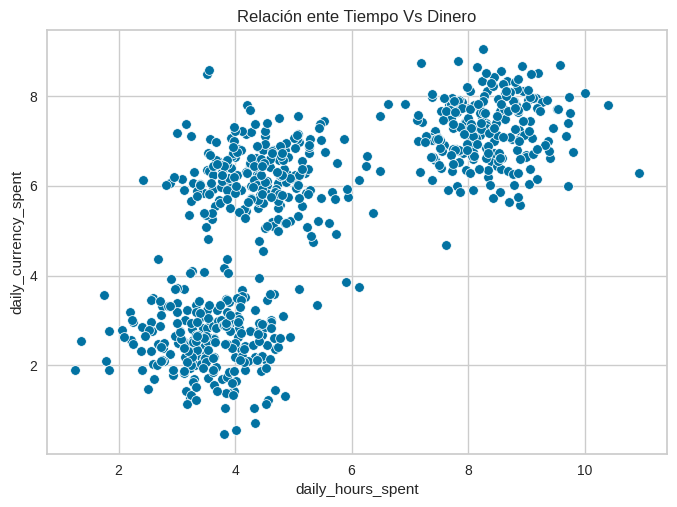

In [ ]:
#Creación del gráfico de dispersión
sns.scatterplot(x='daily_hours_spent', y='daily_currency_spent', data=data)

plt.title("Relación ente Tiempo Vs Dinero")

plt.show()

De la gráfica se observa una relación positiva entre las dos variables, se podria asumir que al aumento de horas dedicadas a videojuegos aumenta la cantidad de dinero invertido. Se resalta desde ahora la agrupación de los datos, en la dispersión.

Creación de un gráfico de boxplot, con el fin de observar la dispersión de cada variable teniendo en cuenta medidas de centralidad y posición.

Box plot para la variable Daily_hours_spent

In [ ]:
#Creación de boxplot variable horas invertidas/ un gráfico interactivo.
fig1 = px.box(data, y='daily_hours_spent',  title="Daily_hours_spent")
fig1.show()

Para la variable Daily_hours_spent se observan datos con poca dispersión hasta el 50% de los mismos. De ahi en adelante hay mayor dispersión generando sesgo.

Por lo tanto, el 50% del tiempo invertido se encuentra 4.54 horas aproximadamente, el valor mínimo 1.25 horas y el 25% llega a 3.70 horas. Lo anterior podría darme información que 4 horas y media el tiempo en video juegos es controlable, pero al superar ello se llega hasta la inversión 10 horas.

Boxplot para la variable daily_currency_spent

In [ ]:
fig2 = px.box(data, y='daily_currency_spent',  title="daily_currency_spent")
fig2.show()

En esta segunda gráfica de donde se evalua la variable que registra el dinero invertido se observa dispersión alta hasta el 50% de los mismo. Y luego poca dispersión. En este caso se resalta que el valor minimo invertido fue de 0.45, el 25% hasta 3 y el 50% ya llegaba a 6 de inversión de dinero virtual.

Finalmente me intereso por la forma de los datos y lo represento a través de una gráfica de densidad.

In [ ]:
variable1 = data['daily_hours_spent']
variable2 = data['daily_currency_spent']

#Creación del gráfico de densidad
fig = ff.create_distplot([variable1, variable2], ['Daily Hours Spent', 'Daily Currency Spent'], bin_size=.2)



fig.show()

# Análisis de Correlación

A continuación se realiza el estudio de la correlación existente entre los datos, a tráves de un mapa  de calor, que representa el coeficiente de correlación de pearson.

<Axes: >

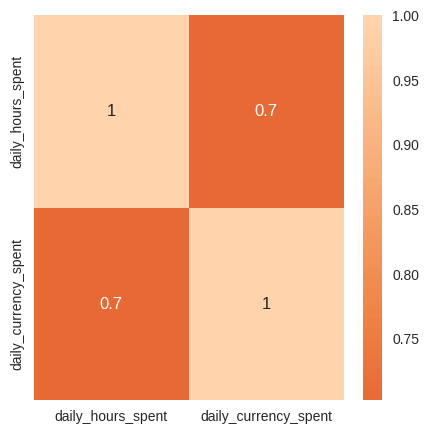

In [ ]:
corrmat= data.corr()
plt.figure(figsize=(5,5))
sns.heatmap(corrmat,annot=True,  center=0)

Como resultado, se verifica una relación positiva con un coeficiente de correlación e 0.7, que resulta representativo para el estudio.

# Clustering k - Medias

Doy inicio al algoritmo de clustering.

Se utiliza el método de Elbow para determinar el número óptimo de clusters mediante una herramienta visual.

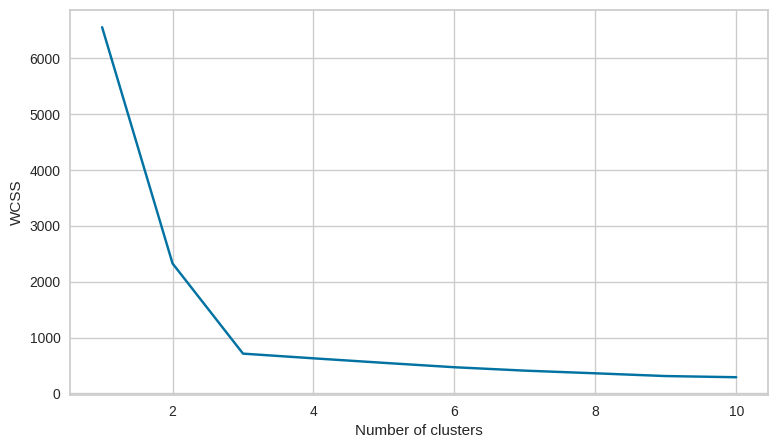

In [ ]:
#Creación de la variable wcss para el almacenamiento de los valores de Within-Cluster Sum of Square

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(data)
    wcss.append(kmeans.inertia_)

# Crear el gráfico del método del codo
plt.figure(figsize=(9, 5))
plt.plot(range(1, 11), wcss)
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

En el gráfico, buscamos un punto en el que la línea comience a aplanarse, lo que indicaría que aumentar el número de clusters no mejora significativamente la varianza explicada. Este punto es conocido como el "codo" y sugiere el número óptimo de clusters para usar en este caso el resultado es k=3

In [ ]:
X = data.values
kmeansmodel = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=0)
y_kmeans = kmeansmodel.fit_predict(X)

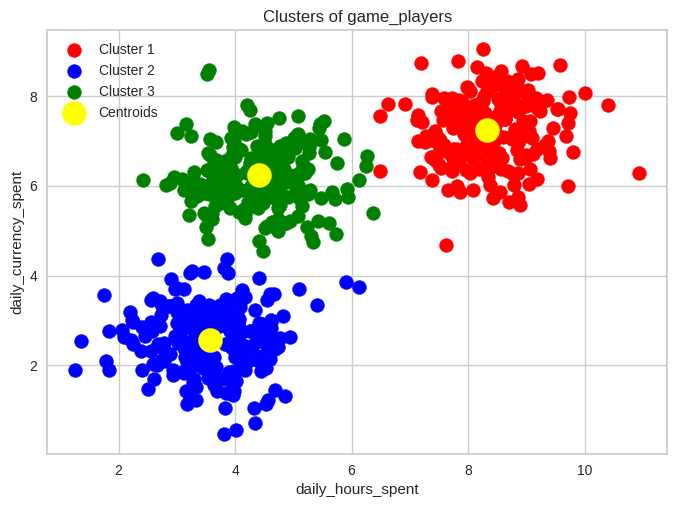

In [ ]:
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(kmeansmodel.cluster_centers_[:, 0], kmeansmodel.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids')
plt.title('Clusters of game_players')
plt.xlabel('daily_hours_spent')
plt.ylabel('daily_currency_spent')
plt.legend()
plt.show()

In [ ]:
silhouette_avg = silhouette_score(X, y_kmeans)
print(f"Puntuación de la Silueta: {silhouette_avg}")

Puntuación de la Silueta: 0.6620176004949123



Se obtiene una puntuación de silueta de aproximadamente 0.66 un resultado relativamente alto y sugiere que el modelo de clustering ha hecho un buen trabajo al asignar las instancias a los clusters

In [ ]:
davies_bouldin = davies_bouldin_score(X, y_kmeans)
print(f"Índice de Davies-Bouldin: {davies_bouldin}")

Índice de Davies-Bouldin: 0.46122176932925224


Una puntuación de 0.66 sugiere que los clusters están bien definidos y separados. Los puntos dentro de un mismo cluster están más cerca entre sí que de los puntos de otros clusters. Este es un indicativo de que el número de clusters seleccionado es bastante adecuado para los datos.

# Conclusiones

Teniendo en cuenta el algoritmo aplicado del conjunto de datos podemos concluir:

* Se obtienen tres Segmentos Distintos: Se identifican claramente tres grupos (clusters) de jugadores basados en las dos variables. Cada cluster representa un segmento de jugadores con hábitos similares de juego y gasto.

* Cluster 1 (Rojo): Este grupo está caracterizado por jugadores que pasan muchas horas jugando diariamente y gastan una cantidad significativa de moneda virtual. Podría interpretarse como los jugadores 'hardcore' que son altamente comprometidos con el juego.

* Cluster 2 (Verde): Los jugadores en este grupo también pasan una buena cantidad de tiempo jugando, pero su gasto en moneda virtual es moderado. Este grupo podría representar a jugadores regulares que están comprometidos pero que posiblemente no invierten tanto en el juego como los del cluster rojo.

* Cluster 3 (Azul): Este grupo gasta menos tiempo y menos moneda virtual comparado con los otros dos clusters. Podrían ser jugadores ocasionales que disfrutan del juego sin un compromiso financiero o de tiempo significativo.

* Centroides (Amarillo): Los puntos amarillos representan el centroide de cada cluster, que es el promedio de todos los puntos dentro de ese cluster. Estos pueden servir como el "perfil promedio" de un jugador dentro de cada segmento.